В данной работе делается предсказание оттока клиентов.

Для оценки качества будет использоваться метрика ROC-AUC.

In [1]:
from sklearn.metrics import roc_auc_score


In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

In [ ]:
!gdown 1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K  # train.csv
!gdown 1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r  # test.csv
!gdown 199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y  # submission.csv

Downloading...
From: https://drive.google.com/uc?id=1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K
To: /content/train.csv
100% 664k/664k [00:00<00:00, 46.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r
To: /content/test.csv
100% 218k/218k [00:00<00:00, 47.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y
To: /content/submission.csv
100% 14.7k/14.7k [00:00<00:00, 15.7MB/s]


In [ ]:
data = pd.read_csv('./train.csv')

In [ ]:

# Числовые признаки
num_cols = [
    'ClientPeriod',
    'MonthlySpending',
    'TotalSpent'
]

# Категориальные признаки
cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]

feature_cols = num_cols + cat_cols
target_col = 'Churn'

In [ ]:
data.sort_values(by='ClientPeriod')

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
2543,0,19.70,,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,0
4598,0,56.05,,Female,0,Yes,Yes,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),0
4326,0,25.35,,Male,0,Yes,Yes,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,0
1048,0,25.75,,Male,0,Yes,Yes,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,0
4002,0,61.90,,Male,0,No,Yes,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3655,72,106.10,7657.4,Female,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),0
5261,72,99.90,7251.7,Female,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,Yes,No,Yes,Yes,No,Two year,No,Bank transfer (automatic),0
2622,72,94.25,6849.75,Female,0,Yes,No,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,No,No,Two year,Yes,Bank transfer (automatic),0
5250,72,84.10,5981.65,Male,1,Yes,No,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),0


## Анализ данных


In [ ]:
data.describe()

,ClientPeriod,MonthlySpending,IsSeniorCitizen,Churn
count,5282.000000,5282.000000,5282.000000,5282.000000
mean,32.397009,64.924754,0.159409,0.262022
std,24.550326,30.176464,0.366092,0.439776
min,0.000000,18.250000,0.000000,0.000000
25%,9.000000,35.462500,0.000000,0.000000
50%,29.000000,70.400000,0.000000,0.000000
75%,55.000000,90.050000,0.000000,1.000000
max,72.000000,118.750000,1.000000,1.000000


In [ ]:
#Проверим есть ли дубликаты. Удалим их
data.duplicated(keep=False).sum()

np.int64(28)

In [ ]:
data.drop_duplicates(inplace=True)

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.describe(include='object')

,TotalSpent,Sex,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod
count,5268,5268,5268,5268,5268,5268,5268,5268,5268,5268,5268,5268,5268,5268,5268,5268
unique,4978,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
freq,9,2647,2691,3662,4747,2497,2335,2604,2324,2309,2596,2091,2073,2906,3140,1780


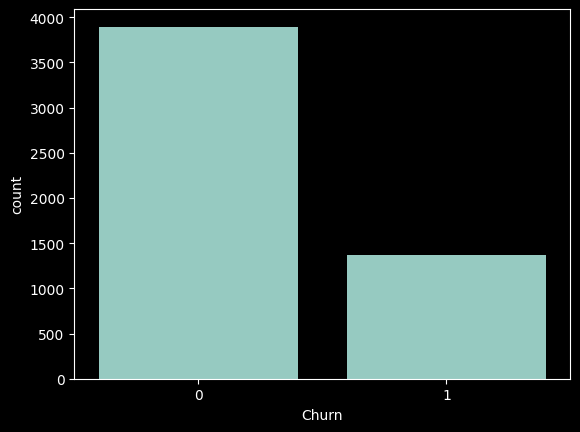

In [ ]:
#Посмотрим на распределение целевой переменной. Видим что классы несбалансированы, 0 примерно в 4 раза больше
plt.style.use('dark_background')
sns.countplot(x=data[target_col])
plt.show()

In [ ]:
#ранне мы заметили что в TotalSpent есть пропуски в виде путсых значений, подумаем чем мы можем их заполнить, посомтрим на эти объекты
data.loc[data['TotalSpent'] == ' ']
#видим что для всех таких объектов client period=0 и для всех целевая переменная =0, можем предположить что это недавно пришедшие к нам клиенты, которые еще не вносили ни одну месячную плату
#поэтому заполним для них TotalSpent нулями

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
1048,0,25.75,,Male,0,Yes,Yes,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,0
1707,0,73.35,,Female,0,Yes,Yes,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,0
2543,0,19.70,,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,0
3078,0,80.85,,Female,0,Yes,Yes,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,0
3697,0,20.00,,Female,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,0
4002,0,61.90,,Male,0,No,Yes,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),0
4326,0,25.35,,Male,0,Yes,Yes,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,0
4551,0,52.55,,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),0
4598,0,56.05,,Female,0,Yes,Yes,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),0


In [ ]:
#заменим пустые значения на np.nan
data.loc[data['TotalSpent'] == ' ', 'TotalSpent'] = np.nan

In [ ]:
#проверим что теперь есть nan значения
data['TotalSpent'].isna().sum()

np.int64(9)

In [ ]:
#поскольку TotalSpent является по сути числовым признаком но имеет тип object, преобразуем его в float
data['TotalSpent']=data['TotalSpent'].astype(float)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5268 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5268 non-null   int64  
 1   MonthlySpending           5268 non-null   float64
 2   TotalSpent                5259 non-null   float64
 3   Sex                       5268 non-null   object 
 4   IsSeniorCitizen           5268 non-null   int64  
 5   HasPartner                5268 non-null   object 
 6   HasChild                  5268 non-null   object 
 7   HasPhoneService           5268 non-null   object 
 8   HasMultiplePhoneNumbers   5268 non-null   object 
 9   HasInternetService        5268 non-null   object 
 10  HasOnlineSecurityService  5268 non-null   object 
 11  HasOnlineBackup           5268 non-null   object 
 12  HasDeviceProtection       5268 non-null   object 
 13  HasTechSupportAccess      5268 non-null   object 
 14  HasOnlineTV  

In [ ]:
#заполним пропуски
data['TotalSpent']=data['TotalSpent'].fillna(0)

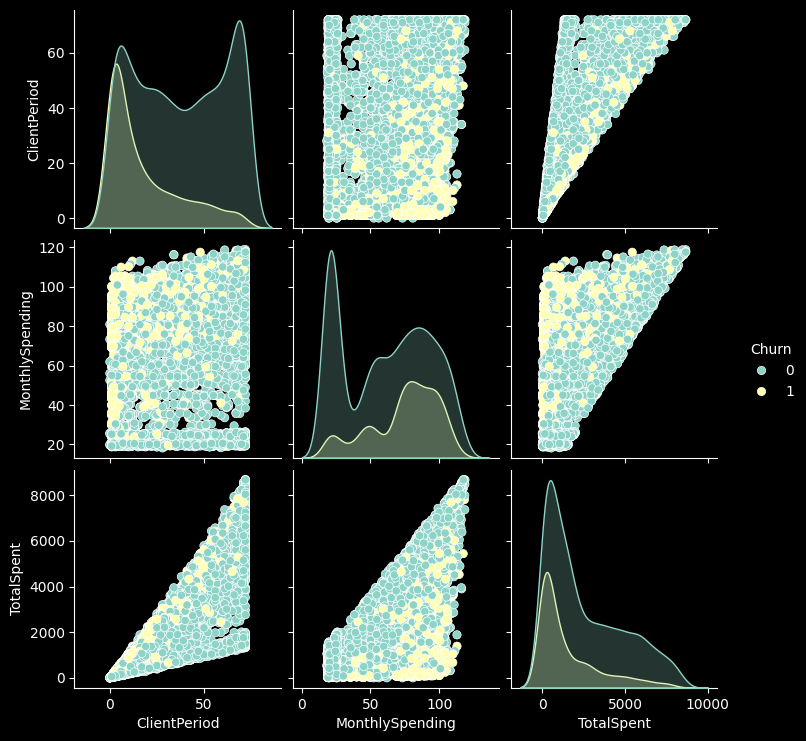

In [ ]:
#посмотрим на корреляции между числовыми признаками
sns.pairplot(data=data[['ClientPeriod', 'MonthlySpending', 'TotalSpent', target_col]], hue=target_col)
#Можем отметить следующие моменты:
#1. Видмим что бОльшая часть клиентов уходят в начале периода пользования, с течением времени вероятность того что клиент уйдет сильно уменьшается
#2. есть сильная корреляция между ClientPeriod и TotalSpent, а также между Monthly Period и Total Spent. Можем предположить, что TotalSpent складывается примерно как ClientPeriod*MonthlySpending
#3. Клиенты с небольшим MonthlySpending наиболе вероятно не уйдут
#4. Клиенты с высоким Monthly Spending массово уходят в начале пользования
#

#

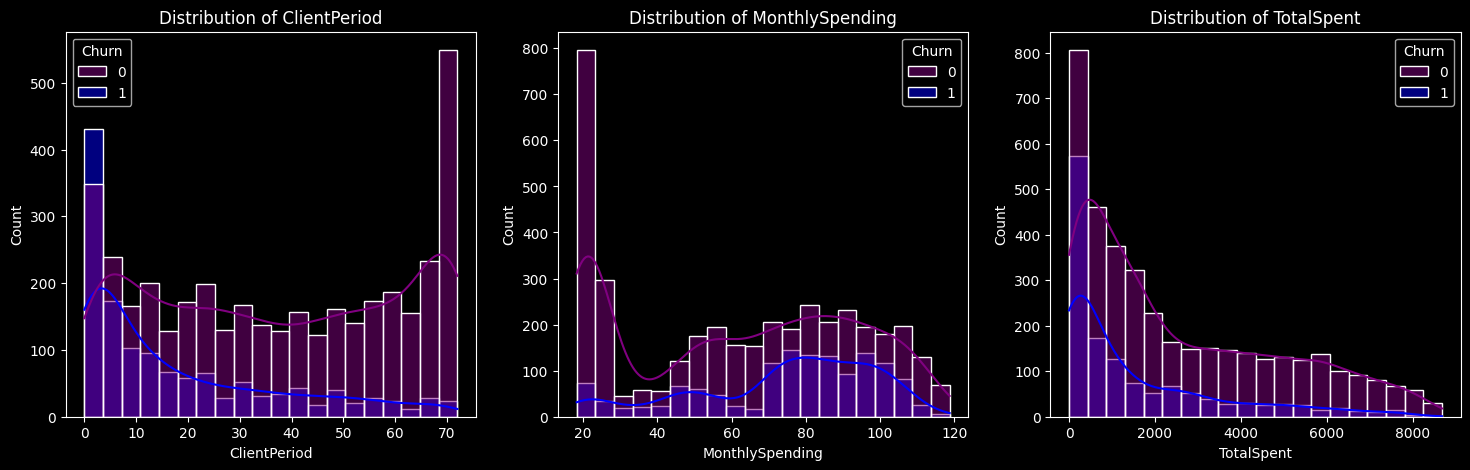

In [ ]:
#посмторим ещзе раз на распределение числовых призанков
#Все имеют ненормальное распредление
#Попробуем что нибудь с ними сделать
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, num_cols):
    sns.histplot(data=data, x=col, kde=True, ax=ax, hue=target_col, palette=['purple', 'blue'], bins=20)
    ax.set_title(f'Distribution of {col}')
    #ax.grid()

In [ ]:
data[num_cols].isna().sum()

,0
ClientPeriod,0
MonthlySpending,0
TotalSpent,0


In [ ]:
#TotalSpent имеет смещенное распредлеение с длинным хвостом справа, попробуем его преобразовать с помощью метода Box-Cox
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='box-cox')
data['TotalSpent']+=0.0001
data['TotalSpent'] = pt.fit_transform(data[['TotalSpent']])

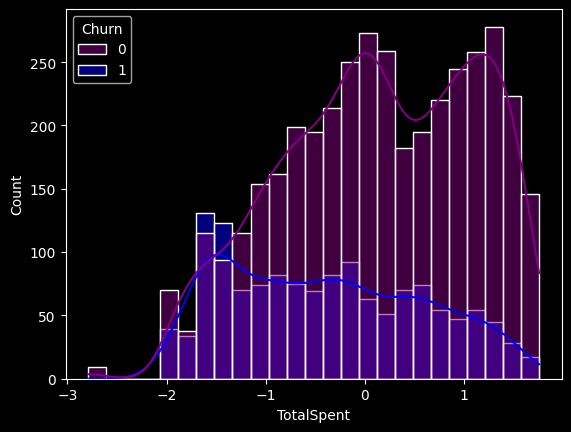

In [ ]:
#в целом выглядит получше. остальные признаки не получилось адекватно преобразовать поэтому оставим как есть
sns.histplot(data=data, x='TotalSpent', kde=True, hue=target_col, palette=['purple', 'blue'])
ax.set_title(f'Distribution of TotalSpent')
ax.grid()

In [ ]:
#убедимся что нигде нет пропусков
data.isna().sum()

,0
ClientPeriod,0
MonthlySpending,0
TotalSpent,0
Sex,0
IsSeniorCitizen,0
HasPartner,0
HasChild,0
HasPhoneService,0
HasMultiplePhoneNumbers,0
HasInternetService,0


In [ ]:
#пржде чем начать работать с ктегориальными признакаами сделаем копию dataset для последующего использования CatBoost
data_cat=data.copy()

In [ ]:
#посомтрим на значения категориальных принзаков. В целом в каждом признаке не очкень много значений. есть признаки которые, как кажестя повторяют друг друга
for cat in cat_cols:
  print(data[cat].unique())

['Male' 'Female']
[0 1]
['Yes' 'No']
['Yes' 'No']
['Yes' 'No']
['No' 'Yes' 'No phone service']
['No' 'Fiber optic' 'DSL']
['No internet service' 'No' 'Yes']
['No internet service' 'No' 'Yes']
['No internet service' 'No' 'Yes']
['No internet service' 'Yes' 'No']
['No internet service' 'No' 'Yes']
['No internet service' 'No' 'Yes']
['One year' 'Two year' 'Month-to-month']
['No' 'Yes']
['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automatic)']


In [ ]:
def cat_graph(pivot_table, category):
  plt.figure(figsize=(8, 6))
  pivot_table.plot(kind='bar', figsize=(7, 4))
  plt.title(f'Распределение целевого признака по {category}')
  plt.ylabel('Количество')
  plt.xlabel(f'{category}')
  plt.legend(title='Churn')
  plt.xticks(rotation=30)
  plt.tight_layout()
  plt.show()

<Figure size 800x600 with 0 Axes>

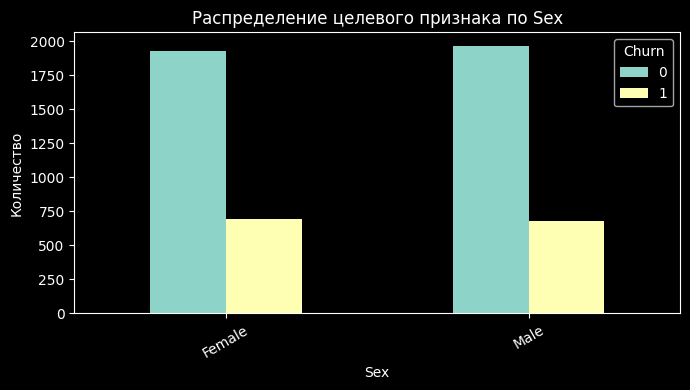

In [ ]:
#посмотри на распредление пола и соотношение с целевым призанком
pivot_data = data.pivot_table(index='Sex', columns=target_col, aggfunc='size')
cat_graph(pivot_data, 'Sex')
#видим, что никак не влияет на целевую переменную

<Figure size 800x600 with 0 Axes>

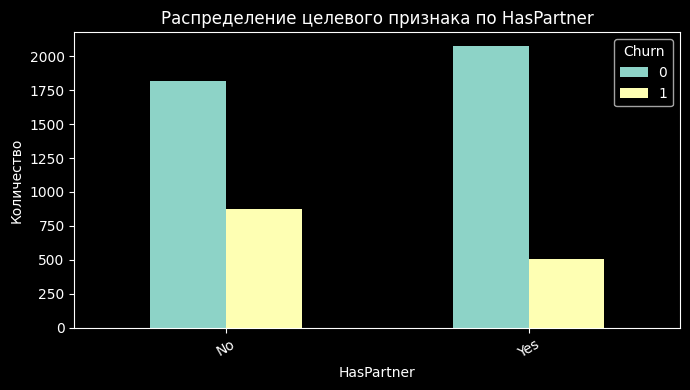

In [ ]:
#аналогично посмотри на признак HasPartner. Тут уже видим что клиенты с партнером меньше уходят
pivot_table=data.pivot_table(index='HasPartner', columns=target_col, aggfunc='size')
cat_graph(pivot_table, 'HasPartner')

<Figure size 800x600 with 0 Axes>

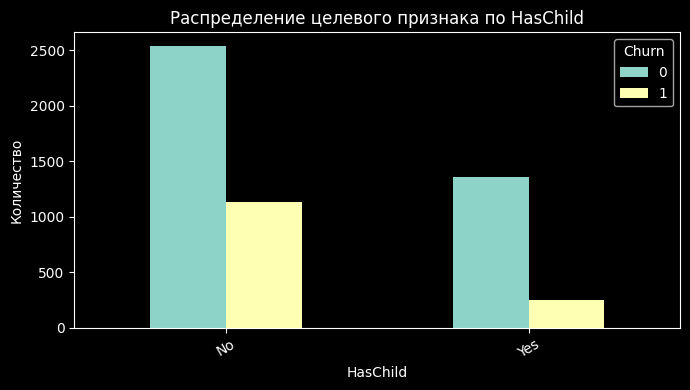

In [ ]:
#аналогично посмотри на признак HasChild. Тут уже видим что клиенты с детьми меньше пользуются нашими услугами и меньше уходят
pivot_table=data.pivot_table(index='HasChild', columns=target_col, aggfunc='size')
cat_graph(pivot_table, 'HasChild')

<Figure size 800x600 with 0 Axes>

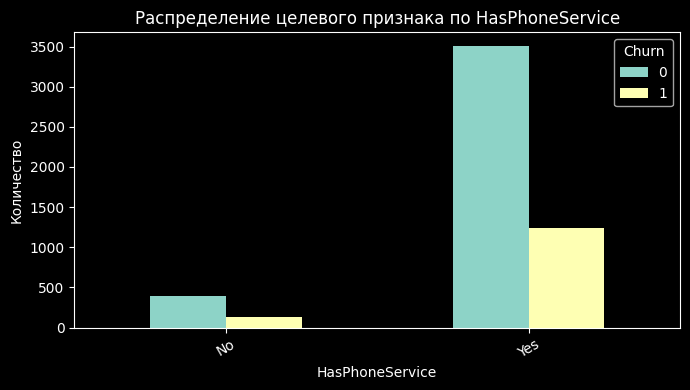

In [ ]:
#аналогично посмотрим на признак HasPhoneService. Видим, что у нас в целом мало (меньше 1000) клиентов без телефонных услуг. БОльшая часть из тех у кого есть остаются
pivot_table=data.pivot_table(index='HasPhoneService', columns=target_col, aggfunc='size')
cat_graph(pivot_table, 'HasPhoneService')

In [ ]:
#Отметим, что  HasMultiplePhoneNumbers дублирует признак HasPhoneService, возможно стоит его удалить, подумаем об этом дальше
no_phone_service=data.loc[data['HasPhoneService']=='No']
no_phone_service['HasPhoneService'].unique()

array(['No'], dtype=object)

<Figure size 800x600 with 0 Axes>

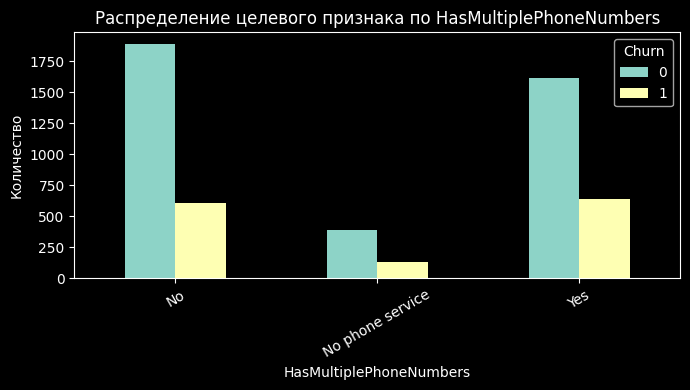

In [ ]:
#аналогично посмотрим на признак HasMultiplePhoneNumber. У большинства есть Phone Service
pivot_table=data.pivot_table(index='HasMultiplePhoneNumbers', columns=target_col, aggfunc='size')
cat_graph(pivot_table, 'HasMultiplePhoneNumbers')

<Figure size 800x600 with 0 Axes>

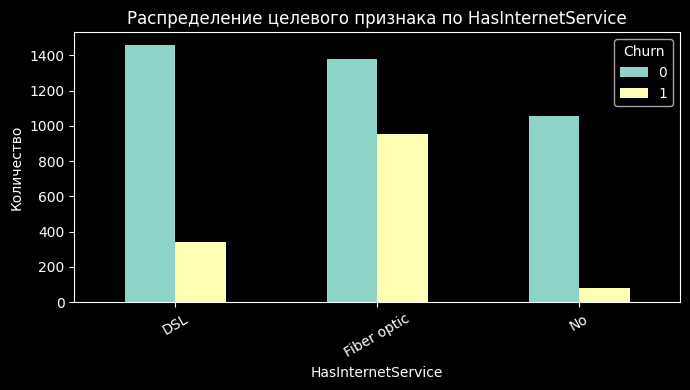

In [ ]:
#аналогично посмотрим на признак 'HasInternetService. Много пользуются Fiber Optic и многие его пользователи уходят. Можем предположить, что качество Fiber Optic низкое.
#Среди тех у кого нет интернета мало уходят
pivot_table=data.pivot_table(index='HasInternetService', columns=target_col, aggfunc='size')
cat_graph(pivot_table, 'HasInternetService')

In [ ]:
#data.drop(['HasPhoneService'], axis=1, inplace=True)

In [ ]:
#Посмотрим сколько пользователи платят за интернет. Самый дорогой Fiber Optic, и от него больше всего уходят. Надо что-то делать с качеством проводного интернета
data.groupby(['HasInternetService'])['MonthlySpending'].mean()

,MonthlySpending
HasInternetService,
DSL,58.004505
Fiber optic,91.655246
No,21.140705


In [ ]:
data[(data['HasInternetService']=='No')&(data['HasMultiplePhoneNumbers']=='No phone service')]

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn


In [ ]:
#Обратим внимание, что есть клиенты, которые пользуются только интернетом, есть которые только телефоном, есть которые и те и те(третьих большинство).
#Разделим на 3 таких группы и посмтрим отличается ли распределение таргета для каждом группы и затраты клиентов из каждой группы
data_internet=data[(data['HasMultiplePhoneNumbers']=='No phone service')&(data['HasInternetService']!='No')]
data_phone=data[(data['HasMultiplePhoneNumbers']!='No phone service')&(data['HasInternetService']=='No')]
data_phone_internet=data[(data['HasMultiplePhoneNumbers']!='No phone service')&(data['HasInternetService']!='No')]
print('Средние затраты клиентов которые пользуются только интернетом: ', data_internet['MonthlySpending'].mean())
print('Средние затраты клиентов которые пользуются только телефоном: ', data_phone['MonthlySpending'].mean())
print('Средние затраты клиентов которые пользуются и телефоном и интернетом: ', data_phone_internet['MonthlySpending'].mean())
print('Доля пользователей интернета, которые ушли: ', len(data_internet[data_internet[target_col]==1])/len(data_internet))
print('Доля пользователей телефона, которые ушли: ', len(data_phone[data_phone[target_col]==1])/len(data_phone))
print('Доля пользователей интернета и телефона, которые ушли: ', len(data_phone_internet[data_phone_internet[target_col]==1])/len(data_phone_internet))
# Видим, что расходы интернет пользователей в два раза больше расходов пользователей телефона. Больше всего у тех кто пользуется и тем и тем (что логично)
# Среди пользователей интернета в три раза больше тех (в пропорциях), которые ушли, чем среди тех кто пользуется только телефоном, можем предположить что услуги интрнета хуже чем услуги телефона.
# Больше всего уходят те кто пользуется и тем и тем

Средние затраты клиентов которые пользуются только интернетом:  42.00441458733205
Средние затраты клиентов которые пользуются только телефоном:  21.14070484581498
Средние затраты клиентов которые пользуются и телефоном и интернетом:  82.06611295681064
Доля пользователей интернета, которые ушли:  0.2476007677543186
Доля пользователей телефона, которые ушли:  0.07048458149779736
Доля пользователей интернета и телефона, которые ушли:  0.3225359911406423


<Figure size 800x600 with 0 Axes>

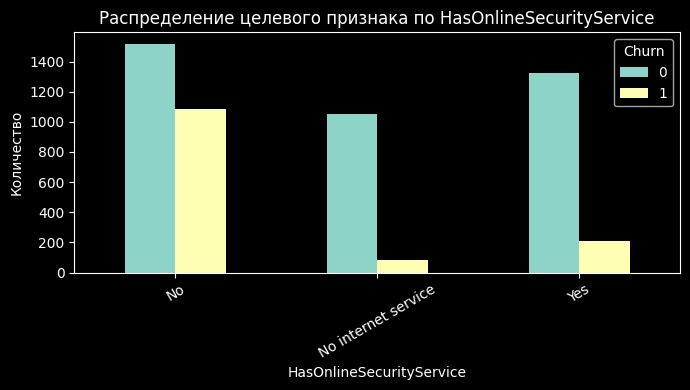

In [ ]:
#аналогично посмотрим на признак 'HasOnlineSecurityService. Много уходят из тех, у кого нет этой опции.
pivot_table=data.pivot_table(index='HasOnlineSecurityService', columns=target_col, aggfunc='size')
cat_graph(pivot_table, 'HasOnlineSecurityService')

<Figure size 800x600 with 0 Axes>

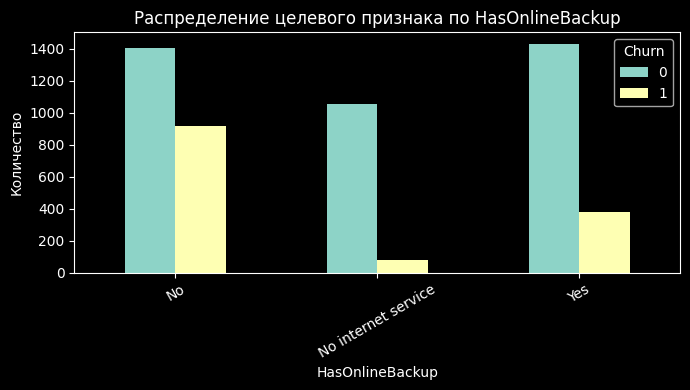

In [ ]:
#аналогично посмотрим на признак 'HasOnlineBackup. Аналогичный вывод как и с прошлым пунктом
pivot_table=data.pivot_table(index='HasOnlineBackup', columns=target_col, aggfunc='size')
cat_graph(pivot_table, 'HasOnlineBackup')

<Figure size 800x600 with 0 Axes>

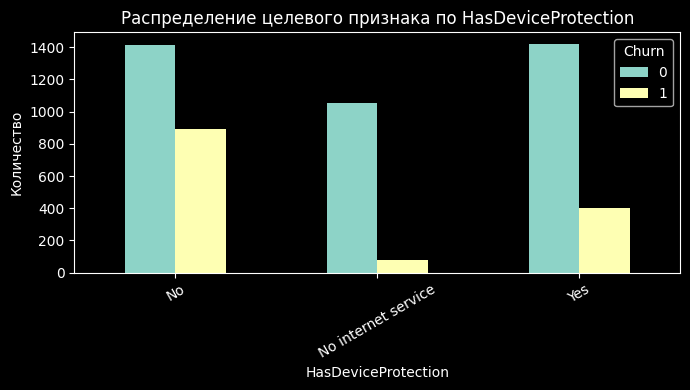

In [ ]:
#аналогично посмотрим на признак 'HasDeviceProtection. Аналогичный вывод как и с прошлым пунктом
pivot_table=data.pivot_table(index='HasDeviceProtection', columns=target_col, aggfunc='size')
cat_graph(pivot_table, 'HasDeviceProtection')

<Figure size 800x600 with 0 Axes>

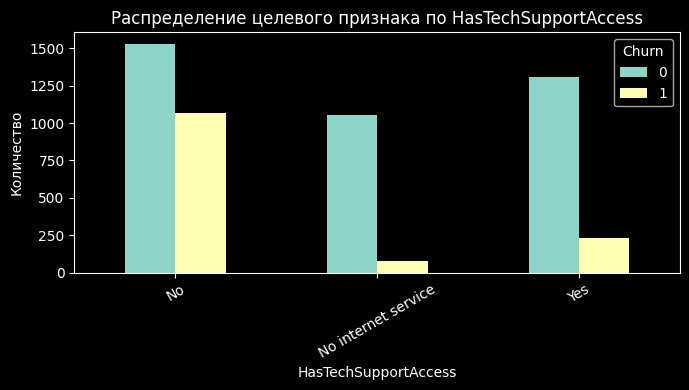

In [ ]:
#аналогично посмотрим на признак 'HasTechSupportAccess. Аналогичный вывод как и с прошлым пунктом
pivot_table=data.pivot_table(index='HasTechSupportAccess', columns=target_col, aggfunc='size')
cat_graph(pivot_table, 'HasTechSupportAccess')

<Figure size 800x600 with 0 Axes>

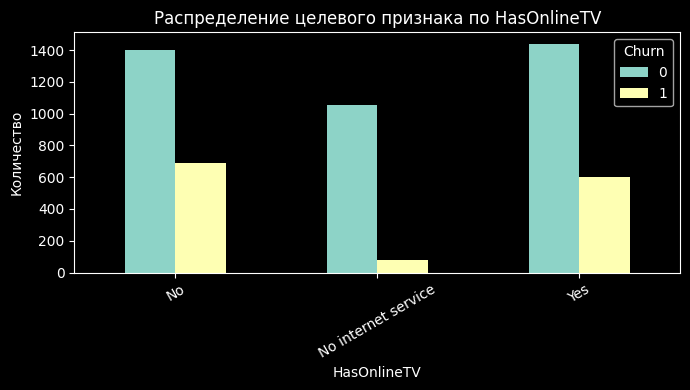

In [ ]:
#аналогично посмотрим на признак HasOnlineTV. Тут не особо отичатеся распределние для тех у кого есть и нет этой опции. Надо подумать стоит дли удалить этот признак
pivot_table=data.pivot_table(index='HasOnlineTV', columns=target_col, aggfunc='size')
cat_graph(pivot_table, 'HasOnlineTV')

<Figure size 800x600 with 0 Axes>

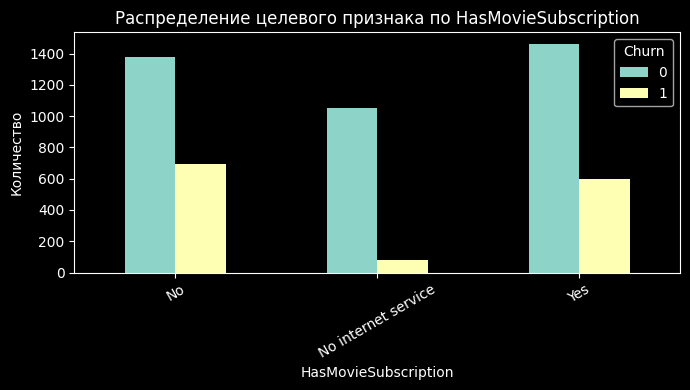

In [ ]:
#аналогично посмотрим на признак 'HasMovieSubscription. Аналогичный вывод как и с прошлым пунктом. Надо подумать стоит ли удалить этот признак
pivot_table=data.pivot_table(index='HasMovieSubscription', columns=target_col, aggfunc='size')
cat_graph(pivot_table, 'HasMovieSubscription')

<Figure size 800x600 with 0 Axes>

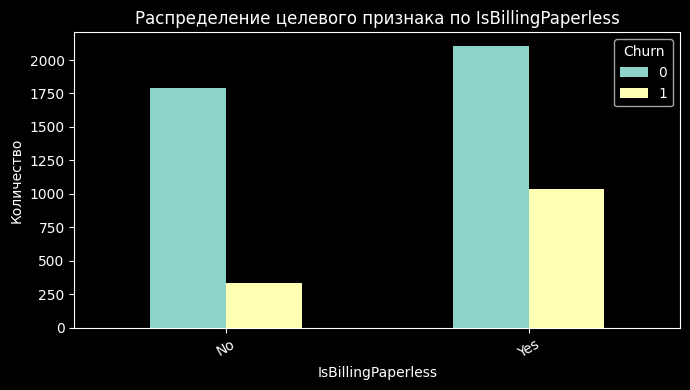

In [ ]:
#аналогично посмотрим на признак 'IsBillingPaperless. Многие уходят из тех у кого paperless биллинг
pivot_table=data.pivot_table(index='IsBillingPaperless', columns=target_col, aggfunc='size')
cat_graph(pivot_table, 'IsBillingPaperless')

<Figure size 800x600 with 0 Axes>

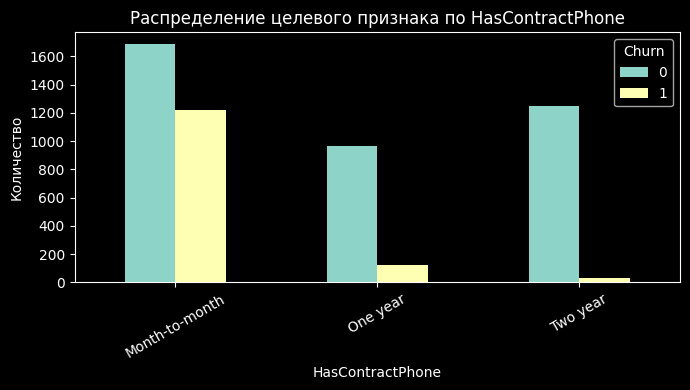

In [ ]:
#аналогично посмотрим на признак HasContractPhone. У большинства month-to-month, многие из таких клиентов уходят. Меньше всего уходят долгосрочные контракты
pivot_table=data.pivot_table(index='HasContractPhone', columns=target_col, aggfunc='size')
cat_graph(pivot_table, 'HasContractPhone')

<Figure size 800x600 with 0 Axes>

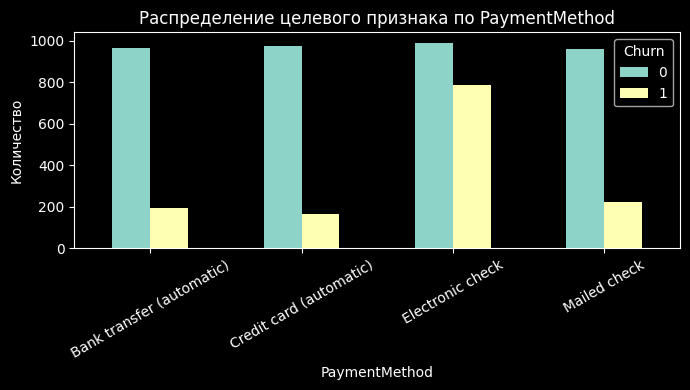

In [ ]:
#аналогично посмотрим на признак PaymentMethod. Больше всего уходят те, у кого electronic check. Остальные значения сильно не отличаются
pivot_table=data.pivot_table(index='PaymentMethod', columns=target_col, aggfunc='size')
cat_graph(pivot_table, 'PaymentMethod')

In [ ]:
#закондируем признаки
data.loc[data['Sex']=='Female', 'Sex']=1
data.loc[data['Sex']=='Male', 'Sex']=0

data.loc[data['HasPartner']=='Yes', 'HasPartner']=1
data.loc[data['HasPartner']=='No', 'HasPartner']=0

data.loc[data['HasChild']=='Yes', 'HasChild']=1
data.loc[data['HasChild']=='No', 'HasChild']=0

data.loc[data['HasPhoneService']=='Yes', 'HasPhoneService']=1
data.loc[data['HasPhoneService']=='No', 'HasPhoneService']=0

data.loc[data['HasMultiplePhoneNumbers']=='Yes', 'HasMultiplePhoneNumbers']=2
data.loc[data['HasMultiplePhoneNumbers']=='No', 'HasMultiplePhoneNumbers']=1
data.loc[data['HasMultiplePhoneNumbers']=='No phone service', 'HasMultiplePhoneNumbers']=0

data.loc[data['HasInternetService']=='DSL', 'HasInternetService']=1
data.loc[data['HasInternetService']=='Fiber optic', 'HasInternetService']=2
data.loc[data['HasInternetService']=='No', 'HasInternetService']=0

data.loc[data['HasOnlineSecurityService']=='No internet service', 'HasOnlineSecurityService']=0
data.loc[data['HasOnlineSecurityService']=='Yes', 'HasOnlineSecurityService']=2
data.loc[data['HasOnlineSecurityService']=='No', 'HasOnlineSecurityService']=1

data.loc[data['HasOnlineBackup']=='No internet service', 'HasOnlineBackup']=0
data.loc[data['HasOnlineBackup']=='Yes', 'HasOnlineBackup']=1
data.loc[data['HasOnlineBackup']=='No', 'HasOnlineBackup']=2

data.loc[data['HasDeviceProtection']=='No internet service', 'HasDeviceProtection']=0
data.loc[data['HasDeviceProtection']=='Yes', 'HasDeviceProtection']=2
data.loc[data['HasDeviceProtection']=='No', 'HasDeviceProtection']=1

data.loc[data['HasTechSupportAccess']=='No internet service', 'HasTechSupportAccess']=0
data.loc[data['HasTechSupportAccess']=='Yes', 'HasTechSupportAccess']=2
data.loc[data['HasTechSupportAccess']=='No', 'HasTechSupportAccess']=1

data.loc[data['HasOnlineTV']=='No internet service', 'HasOnlineTV']=0
data.loc[data['HasOnlineTV']=='Yes', 'HasOnlineTV']=2
data.loc[data['HasOnlineTV']=='No', 'HasOnlineTV']=1

data.loc[data['HasMovieSubscription']=='No internet service', 'HasMovieSubscription']=0
data.loc[data['HasMovieSubscription']=='Yes', 'HasMovieSubscription']=2
data.loc[data['HasMovieSubscription']=='No', 'HasMovieSubscription']=1

data.loc[data['IsBillingPaperless']=='Yes', 'IsBillingPaperless']=1
data.loc[data['IsBillingPaperless']=='No', 'IsBillingPaperless']=0

data.loc[data['HasContractPhone']=='One year', 'HasContractPhone']=1
data.loc[data['HasContractPhone']=='Two year', 'HasContractPhone']=2
data.loc[data['HasContractPhone']=='Month-to-month', 'HasContractPhone']=0

data.loc[data['PaymentMethod']=='Bank transfer (automatic)', 'PaymentMethod']=1
data.loc[data['PaymentMethod']=='Credit card (automatic)', 'PaymentMethod']=0
data.loc[data['PaymentMethod']=='Electronic check', 'PaymentMethod']=3
data.loc[data['PaymentMethod']=='Mailed check', 'PaymentMethod']=2

In [ ]:
#постмотри на корреляции между признаками, выведем только те значеня где корреляция больше 0.3 по модулю. Видим что таких довольно много
cors=data.corr()
cors[(cors>0.3) | (cors<-0.3)]

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
ClientPeriod,1.000000,NaN,0.866357,NaN,NaN,0.368264,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.671876,NaN,-0.331402,-0.348881
MonthlySpending,NaN,1.000000,0.619907,NaN,NaN,NaN,NaN,NaN,0.487297,0.904919,0.631945,0.534031,0.736485,0.655759,0.821859,0.819270,NaN,0.344124,NaN,NaN
TotalSpent,0.866357,0.619907,1.000000,NaN,NaN,0.322866,NaN,NaN,0.397139,0.410254,0.480428,NaN,0.533910,0.482547,0.518838,0.529106,0.447022,NaN,NaN,NaN
Sex,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IsSeniorCitizen,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HasPartner,0.368264,NaN,0.322866,NaN,NaN,1.000000,0.441631,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HasChild,NaN,NaN,NaN,NaN,NaN,0.441631,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HasPhoneService,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00000,0.680360,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HasMultiplePhoneNumbers,NaN,0.487297,0.397139,NaN,NaN,NaN,NaN,0.68036,1.000000,0.302615,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HasInternetService,NaN,0.904919,0.410254,NaN,NaN,NaN,NaN,NaN,0.302615,1.000000,0.580373,0.685473,0.662427,0.582441,0.730295,0.724030,NaN,0.369356,NaN,0.311357


In [ ]:
#для наглядности посмотрим на heatmap
# Видим что есть сильная корреляция между TotalSpent и MonthlyPeriod
#Sex вообще ни с чем не коррелирует, полагаю что это признак просто создает лишний шум, удалим этот признак
# Есть корреляция между признаками, связанными с интренетом
#Movie Subscription и OnlineTV дорого стоят
# Вообще интернет самый дорогой (корреляция 0.9 с расходами)
# Наиболле всего с таргетом коррелирует Client Period, HasContactPhone, HasInternetService
#Поскольку многие признаки сильно коррелируют, попробуем удалить некоторые из них и поэкспериментируем ниже как это повлияет на качество наших моделей
import plotly.express as px
fig = px.imshow(
    cors,
    color_continuous_scale='purples',
    title='Корреляция признаков и целевой переменной',
    width=1200,
    height=1200
)
fig.show()

In [ ]:
#поэксприментировав решаем удалить признаки следующим образом:
data.drop(columns=['Sex', 'HasMultiplePhoneNumbers', 'HasOnlineTV', 'HasMovieSubscription'], inplace=True)
data_cat.drop(columns=['Sex'], inplace=True)
cat_cols=['HasMultiplePhoneNumbers', 'HasOnlineTV', 'HasMovieSubscription', 'IsSeniorCitizen',	'HasPartner',	'HasChild',
 'HasPhoneService',
 'HasInternetService',
 'HasOnlineSecurityService',
 'HasOnlineBackup',
 'HasDeviceProtection',
 'HasTechSupportAccess',
 'HasContractPhone',
 'IsBillingPaperless',
 'PaymentMethod']

Применим и обучим  модели

In [ ]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import make_pipeline

In [ ]:
#создаем X и y
X = data.drop([target_col], axis=1)
y = data[target_col]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y, shuffle=True)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val=pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
#интересно посмотреть на распределение объектов в признаковом пространстве, используем PCA чтобы снизить пространственность до 2 и визуализировать объекты
from sklearn.decomposition import PCA
pca=PCA(2)
data_scaled=scaler.fit_transform(X)
data_pca=pd.DataFrame(pca.fit_transform(data_scaled), columns=['1', '2'])

In [ ]:
data_pca

,1,2
0,-3.642197,2.082987
1,-3.206246,3.125698
2,0.641144,-2.886388
3,1.551887,-0.714588
4,2.716275,3.106166
...,...,...
5263,-0.745399,-2.406827
5264,1.265936,0.708157
5265,0.018874,-2.159078
5266,0.854101,-0.868640


In [ ]:
data_pca=pd.concat([data_pca, y.reset_index()], axis=1)

In [ ]:
data_pca.drop(columns='index', inplace=True)

In [ ]:
data_pca

,1,2,Churn
0,-3.642197,2.082987,0
1,-3.206246,3.125698,0
2,0.641144,-2.886388,1
3,1.551887,-0.714588,0
4,2.716275,3.106166,0
...,...,...,...
5263,-0.745399,-2.406827,0
5264,1.265936,0.708157,0
5265,0.018874,-2.159078,0
5266,0.854101,-0.868640,0


<Axes: xlabel='1', ylabel='2'>

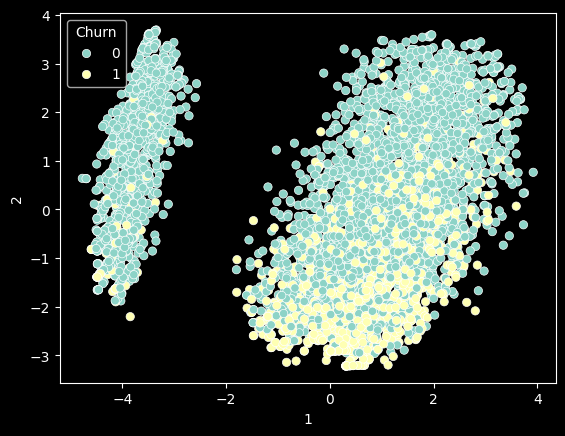

In [ ]:
#видим отделившееся облако почти полностью с объектами 0 значения таргета. Можно сделать доп анализ и поизучать что это за объекты, но пока перейдем к обучению
sns.scatterplot(data=data_pca, x='1', y='2', hue='Churn')

In [ ]:
# поэкспериментировала с обучением с PCA и без, без PCA получилось немного качественнее, поэтому закомментирую код и не будем применять

# pca=PCA(n_components=0.95)
# X_train_pca=pca.fit_transform(X_train)
# X_val_pca=pca.transform(X_val)

In [ ]:
# train_index = X_train.index
# val_index = X_val.index
# X_train = pd.DataFrame(X_train_pca, index=train_index,
#                              columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])
# X_val = pd.DataFrame(X_val_pca, index=val_index,
#                             columns=[f'PC{i+1}' for i in range(X_val_pca.shape[1])])

In [ ]:
# Обучим логистическиую регрессию, поэкспериментировала лучшее качество получилось на С=0.1
model_logistic=LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000,
                   penalty='l1', random_state=42, solver='saga')
model_logistic.fit(X_train, y_train)
y_logistic_predict=model_logistic.predict(X_val)
y_train_logistic_predict=model_logistic.predict(X_train)

y_logistic_predict_p=model_logistic.predict_proba(X_val)[:, 1]
y_train_logistic_predict_p=model_logistic.predict_proba(X_train)[:, 1]

In [ ]:
# #создадим также другие модели RandomForest, DecisionTree, KNN для сравнения

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
rf_grid=GridSearchCV(RandomForestClassifier(random_state=42, class_weight='balanced'),
                  param_grid={'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_leaf': [3, 5, 10],
        'min_samples_split': [2, 5, 10]},
                          cv=5,  scoring='roc_auc',
                          n_jobs=-1, return_train_score=True, verbose=5)


In [ ]:
rf_grid.fit(X_train, y_train)
print(rf_grid.best_score_)

In [ ]:
rf_grid

In [ ]:
model_rf=RandomForestClassifier(class_weight='balanced', max_depth=8,
                       min_samples_leaf=30, n_estimators=300, random_state=42, max_features='sqrt',
                      max_samples=0.8, bootstrap=True)
model_rf.fit(X_train, y_train)
y_rf_predict=model_rf.predict(X_val)
y_train_rf_predict=model_rf.predict(X_train)

y_rf_predict_p=model_rf.predict_proba(X_val)[:, 1]
y_train_rf_predict_p=model_rf.predict_proba(X_train)[:, 1]

In [ ]:
model_knn=KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)
y_knn_predict=model_knn.predict(X_val)
y_train_knn_predict=model_knn.predict(X_train)

y_knn_predict_p=model_knn.predict_proba(X_val)[:, 1]
y_train_knn_predict_p=model_knn.predict_proba(X_train)[:, 1]

In [ ]:

dt_grid=GridSearchCV(DecisionTreeClassifier(random_state=42, class_weight='balanced'),
                     param_grid={'max_depth':range(1, 20),
                                 'min_samples_leaf': range(1, 20)},
                     scoring='roc_auc', cv=5, n_jobs=-1, return_train_score=True, verbose=5)

In [ ]:
dt_grid.fit(X_train, y_train)
print(dt_grid.best_score_)

In [ ]:
dt_grid

In [ ]:
model_dt=DecisionTreeClassifier(class_weight='balanced', max_depth=4,
                       min_samples_leaf=15, random_state=42)
model_dt.fit(X_train, y_train)
y_dt_predict=model_dt.predict(X_val)
y_train_dt_predict=model_dt.predict(X_train)

y_dt_predict_p=model_dt.predict_proba(X_val)[:, 1]
y_train_dt_predict_p=model_dt.predict_proba(X_train)[:, 1]

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

In [ ]:
#посомтри на метрики
def assess_quality(y_true_test, y_pred_test, y_true_train, y_pred_train, y_val_pred_proba, y_train_pred_proba):
  accuracy=accuracy_score(y_true_test, y_pred_test)
  accuracy_train=accuracy_score(y_true_train, y_pred_train)
  print("Accuracy train: %.4f" % accuracy_train)
  print("Accuracy test: %.4f" % accuracy)
  print("---")

  precision=precision_score(y_true_test, y_pred_test)
  precision_train=precision_score(y_true_train, y_pred_train)
  print("Precision train: %.4f" % precision_train)
  print("Precision test: %.4f" % precision)
  print("---")

  recall=recall_score(y_true_test, y_pred_test)
  recall_train=recall_score(y_true_train, y_pred_train)
  print("Recall train: %.4f" % recall_train)
  print("Recall test: %.4f" % recall)
  print("---")

  f1=f1_score(y_true_test, y_pred_test)
  f1_train=f1_score(y_true_train, y_pred_train)
  print("F1 train: %.4f" % f1_train)
  print("F1 test: %.4f" % f1)
  print("---")

  roc_auc_val = roc_auc_score(y_true_test, y_val_pred_proba)
  roc_auc_train = roc_auc_score(y_true_train, y_train_pred_proba)
  roc_train=roc_auc_score(y_true_train, y_pred_train)
  print("ROC AUC train: %.4f" % roc_auc_train)
  print("ROC AUC test: %.4f" % roc_auc_val)
  print("---")


In [ ]:
assess_quality(y_val, y_logistic_predict, y_train, y_train_logistic_predict, y_logistic_predict_p, y_train_logistic_predict_p)

Accuracy train: 0.7442
Accuracy test: 0.7603
---
Precision train: 0.5062
Precision test: 0.5261
---
Recall train: 0.8119
Recall test: 0.8083
---
F1 train: 0.6236
F1 test: 0.6373
---
ROC AUC train: 0.8446
ROC AUC test: 0.8573
---


In [ ]:
feature_importance_lg = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model_logistic.coef_[0],
    'abs_importance': abs(model_logistic.coef_[0])
}).sort_values('abs_importance', ascending=False)

In [ ]:
feature_importance_lg

,feature,coefficient,abs_importance
1,MonthlySpending,0.785611,0.785611
12,HasContractPhone,-0.767926,0.767926
2,TotalSpent,-0.694895,0.694895
7,HasInternetService,0.302430,0.302430
8,HasOnlineSecurityService,-0.256745,0.256745
9,HasOnlineBackup,0.194414,0.194414
14,PaymentMethod,0.191597,0.191597
6,HasPhoneService,-0.189233,0.189233
13,IsBillingPaperless,0.189045,0.189045
11,HasTechSupportAccess,-0.162626,0.162626


In [ ]:
odds_ratios = np.exp(model_logistic.coef_[0])
odds_ratios

array([1.        , 2.19374663, 0.49912693, 1.11712712, 1.        ,
       0.94464466, 0.8275939 , 1.3531436 , 0.77356514, 1.21459858,
       1.        , 0.84990908, 0.46397424, 1.20809569, 1.21118191])

In [ ]:
assess_quality(y_val, y_rf_predict, y_train, y_train_rf_predict, y_rf_predict_p, y_train_rf_predict_p)

Accuracy train: 0.7635
Accuracy test: 0.7666
---
Precision train: 0.5300
Precision test: 0.5355
---
Recall train: 0.8264
Recall test: 0.7864
---
F1 train: 0.6458
F1 test: 0.6372
---
ROC AUC train: 0.8615
ROC AUC test: 0.8519
---


In [ ]:
feature_importance_rf = pd.DataFrame({
    'feature': X.columns,
    'importance': model_rf.feature_importances_
}).sort_values('importance', ascending=False)
feature_importance_rf

,feature,importance
12,HasContractPhone,0.264620
0,ClientPeriod,0.181085
2,TotalSpent,0.097631
14,PaymentMethod,0.082861
7,HasInternetService,0.078818
1,MonthlySpending,0.070297
8,HasOnlineSecurityService,0.054558
11,HasTechSupportAccess,0.053358
9,HasOnlineBackup,0.043079
10,HasDeviceProtection,0.032629


In [ ]:
assess_quality(y_val, y_knn_predict, y_train, y_train_knn_predict, y_knn_predict_p, y_train_knn_predict_p)

Accuracy train: 0.8359
Accuracy test: 0.7679
---
Precision train: 0.7245
Precision test: 0.5623
---
Recall train: 0.5988
Recall test: 0.4927
---
F1 train: 0.6557
F1 test: 0.5252
---
ROC AUC train: 0.8942
ROC AUC test: 0.7730
---


In [ ]:
assess_quality(y_val, y_dt_predict, y_train, y_train_dt_predict, y_dt_predict_p, y_train_dt_predict_p)

Accuracy train: 0.7204
Accuracy test: 0.7154
---
Precision train: 0.4798
Precision test: 0.4735
---
Recall train: 0.8524
Recall test: 0.8252
---
F1 train: 0.6140
F1 test: 0.6018
---
ROC AUC train: 0.8355
ROC AUC test: 0.8398
---


Применим CatBoostClassifier

In [ ]:
#обучаем catboost
data_cat

,ClientPeriod,MonthlySpending,TotalSpent,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
0,55,19.50,-0.210956,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0
1,72,25.85,0.237431,0,Yes,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),0
2,1,75.90,-1.508998,0,No,No,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,1
3,32,79.30,0.503863,1,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Mailed check,0
4,60,115.25,1.468953,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5277,3,30.40,-1.481251,0,No,No,No,No phone service,DSL,No,No,No,Yes,No,No,Month-to-month,No,Electronic check,0
5278,50,44.45,0.365925,0,Yes,No,No,No phone service,DSL,Yes,No,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),0
5279,1,55.05,-1.615871,0,No,No,Yes,No,DSL,No,No,Yes,Yes,No,No,Month-to-month,No,Mailed check,0
5280,29,76.00,0.376169,0,No,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),0


In [ ]:
!pip install catboost
import catboost
from catboost import CatBoostClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.7 MB/s eta 0:00:00


In [ ]:
!pip install optuna.integration
from optuna.integration import OptunaSearchCV

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 11.9 MB/s eta 0:00:00


In [ ]:
# !pip install optuna.distributions
from optuna.distributions import IntDistribution, FloatDistribution

In [ ]:
X_cat = data_cat.drop([target_col], axis=1)
y_cat = data_cat[target_col]

In [ ]:
# не забудьте в функции train_test_split задать параметр random_state,
# чтобы обеспечить повторяемость разбиения выборки на train и validation части.
# Это позволит сравнивать метрики моделей с различными методами подготовки признаков
X_cat_train, X_cat_val, y_cat_train, y_cat_val = train_test_split(X_cat, y_cat, test_size=0.3, random_state=42, stratify=y, shuffle=True)

In [ ]:
#обучим пока без подбора гиперпараметров
model_boost = catboost.CatBoostClassifier(cat_features=cat_cols)

model_boost.fit(X_cat_train, y_cat_train)

boost_train_predicted = model_boost.predict(X_cat_train)
boost_val_predicted = model_boost.predict(X_cat_val)

Learning rate set to 0.017985
0:	learn: 0.6828472	total: 106ms	remaining: 1m 45s
1:	learn: 0.6726257	total: 172ms	remaining: 1m 26s
2:	learn: 0.6628063	total: 216ms	remaining: 1m 11s
3:	learn: 0.6527665	total: 251ms	remaining: 1m 2s
4:	learn: 0.6437256	total: 282ms	remaining: 56.1s
5:	learn: 0.6347189	total: 316ms	remaining: 52.3s
6:	learn: 0.6268138	total: 338ms	remaining: 48s
7:	learn: 0.6190928	total: 374ms	remaining: 46.3s
8:	learn: 0.6120393	total: 398ms	remaining: 43.8s
9:	learn: 0.6045302	total: 441ms	remaining: 43.6s
10:	learn: 0.5978110	total: 473ms	remaining: 42.5s
11:	learn: 0.5904327	total: 498ms	remaining: 41s
12:	learn: 0.5827155	total: 524ms	remaining: 39.8s
13:	learn: 0.5753538	total: 548ms	remaining: 38.6s
14:	learn: 0.5686943	total: 562ms	remaining: 36.9s
15:	learn: 0.5617874	total: 577ms	remaining: 35.5s
16:	learn: 0.5562227	total: 583ms	remaining: 33.7s
17:	learn: 0.5508824	total: 588ms	remaining: 32.1s
18:	learn: 0.5452930	total: 604ms	remaining: 31.2s
19:	learn: 0

In [ ]:
boost_train_predicted_p = model_boost.predict_proba(X_cat_train)[:, 1]
boost_val_predicted_p = model_boost.predict_proba(X_cat_val)[:, 1]

In [ ]:
assess_quality(y_cat_val, boost_val_predicted, y_cat_train, boost_train_predicted, boost_val_predicted_p, boost_train_predicted_p)

Accuracy train: 0.8313
Accuracy test: 0.8102
---
Precision train: 0.7202
Precision test: 0.6750
---
Recall train: 0.5780
Recall test: 0.5243
---
F1 train: 0.6413
F1 test: 0.5902
---
ROC AUC train: 0.8927
ROC AUC test: 0.8474
---


In [ ]:
from sklearn.model_selection import StratifiedKFold

In [ ]:
#теперь подберем гиперпараметры с помощью Optuna
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
searcher = OptunaSearchCV(
    CatBoostClassifier(random_state=42, verbose=0, cat_features=cat_cols, auto_class_weights='Balanced'),
    param_distributions={
        'iterations': IntDistribution(low=50, high=500),
        'depth': IntDistribution(low=2, high=7),
        'learning_rate': FloatDistribution(low=0.01, high=0.3),
        'l2_leaf_reg': FloatDistribution(low=1, high=10),
        'random_strength': FloatDistribution(low=0.1, high=10)
    },
    cv=cv,
    n_trials=15,
    scoring='roc_auc',
    verbose=10,
    random_state=101
)

/tmp/ipython-input-1413155001.py:3: ExperimentalWarning:

OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.



In [ ]:
cb_optuna=searcher.fit(X_cat_train, y_cat_train)

[I 2025-10-18 15:32:36,318] A new study created in memory with name: no-name-001f99dd-ad05-4831-97c2-d6f0c59d9c93
INFO:optuna_integration.sklearn.sklearn:Searching the best hyperparameters using 3687 samples...
[I 2025-10-18 15:33:02,958] Trial 0 finished with value: 0.8197540738045458 and parameters: {'iterations': 432, 'depth': 4, 'learning_rate': 0.2743200486763212, 'l2_leaf_reg': 9.122474343525083, 'random_strength': 4.7142622575245205}. Best is trial 0 with value: 0.8197540738045458.
[I 2025-10-18 15:33:08,126] Trial 1 finished with value: 0.8392225517573854 and parameters: {'iterations': 137, 'depth': 5, 'learning_rate': 0.2123614546063006, 'l2_leaf_reg': 3.587174214124248, 'random_strength': 7.139779752177984}. Best is trial 1 with value: 0.8392225517573854.
[I 2025-10-18 15:33:29,270] Trial 2 finished with value: 0.8181786230218737 and parameters: {'iterations': 348, 'depth': 6, 'learning_rate': 0.2533209882433316, 'l2_leaf_reg': 7.976271801231743, 'random_strength': 6.10118288

In [ ]:
cb_optuna.best_params_

{'iterations': 199,
 'depth': 2,
 'learning_rate': 0.10404005745371701,
 'l2_leaf_reg': 1.0156245796375245,
 'random_strength': 9.942034365670338}

In [ ]:
model_boost = catboost.CatBoostClassifier(iterations=199,
 depth=2,
 learning_rate=0.10404005745371701,
 l2_leaf_reg=1.0156245796375245,
 random_strength=9.942034365670338,
  cat_features=cat_cols)

model_boost.fit(X_cat_train, y_cat_train)

boost_train_predicted = model_boost.predict(X_cat_train)
boost_val_predicted = model_boost.predict(X_cat_val)

boost_train_predicted_p = model_boost.predict_proba(X_cat_train)[:, 1]
boost_val_predicted_p = model_boost.predict_proba(X_cat_val)[:, 1]

0:	learn: 0.6706195	total: 1.87ms	remaining: 370ms
1:	learn: 0.6432230	total: 4.95ms	remaining: 488ms
2:	learn: 0.6208783	total: 7.07ms	remaining: 462ms
3:	learn: 0.5995865	total: 8.9ms	remaining: 434ms
4:	learn: 0.5838249	total: 10.8ms	remaining: 419ms
5:	learn: 0.5684931	total: 12.8ms	remaining: 411ms
6:	learn: 0.5589459	total: 19.6ms	remaining: 539ms
7:	learn: 0.5501097	total: 22.7ms	remaining: 542ms
8:	learn: 0.5442459	total: 25.6ms	remaining: 541ms
9:	learn: 0.5377240	total: 27.9ms	remaining: 528ms
10:	learn: 0.5329392	total: 30.3ms	remaining: 518ms
11:	learn: 0.5232168	total: 33.5ms	remaining: 522ms
12:	learn: 0.5167066	total: 35.8ms	remaining: 512ms
13:	learn: 0.5099563	total: 37.9ms	remaining: 501ms
14:	learn: 0.5069828	total: 41ms	remaining: 503ms
15:	learn: 0.5027380	total: 42.9ms	remaining: 491ms
16:	learn: 0.4974589	total: 44.9ms	remaining: 481ms
17:	learn: 0.4920979	total: 47.1ms	remaining: 473ms
18:	learn: 0.4894330	total: 49.1ms	remaining: 465ms
19:	learn: 0.4889499	tota

In [ ]:
assess_quality(y_cat_val, boost_val_predicted, y_cat_train, boost_train_predicted, boost_val_predicted_p, boost_train_predicted_p)

Accuracy train: 0.8044
Accuracy test: 0.8159
---
Precision train: 0.6567
Precision test: 0.6885
---
Recall train: 0.5249
Recall test: 0.5364
---
F1 train: 0.5835
F1 test: 0.6030
---
ROC AUC train: 0.8522
ROC AUC test: 0.8542
---


In [ ]:
#также стедлаем staking с нашими простыми моделями выше и обучим meta модель логичстической регрессии
from sklearn.model_selection import cross_val_predict
def get_meta_models(model, X_train, y_train, X_val, cv=5):
  train_pred=cross_val_predict(model, X_train, y_train, cv=cv, method='predict_proba')
  model.fit(X_train, y_train)
  test_pred=model.predict_proba(X_val)
  return train_pred, test_pred

In [ ]:
models=[model_logistic, model_rf, model_dt, model_knn]

In [ ]:
meta_features_train=np.zeros((X_train.shape[0], len(models)))
meta_features_test=np.zeros((X_val.shape[0], len(models)))

In [ ]:
for i, m in tqdm(enumerate(models)):
  x_train, x_test=get_meta_models(m, X_train, y_train, X_val)
  meta_features_train[:, i]=x_train[:, 1]
  meta_features_test[:, i]=x_test[:, 1]

0it [00:00, ?it/s]

In [ ]:
meta_features_test

array([[0.44590749, 0.42301621, 0.50127933, 0.4       ],
       [0.76783177, 0.72405534, 0.79554924, 0.8       ],
       [0.91819088, 0.91520701, 0.95366907, 0.6       ],
       ...,
       [0.49487813, 0.40214506, 0.39634387, 0.4       ],
       [0.33567741, 0.29677504, 0.39634387, 0.        ],
       [0.13886386, 0.10542735, 0.        , 0.        ]])

In [ ]:
meta_model=LogisticRegression(class_weight='balanced', random_state=42, solver='saga', C=0.1)
meta_model.fit(meta_features_train, y_train)

meta_train_predicted = meta_model.predict(meta_features_train)
meta_val_predicted = meta_model.predict(meta_features_test)

meta_train_predicted_p = meta_model.predict_proba(meta_features_train)[:, 1]
meta_val_predicted_p = meta_model.predict_proba(meta_features_test)[:, 1]

In [ ]:
assess_quality(y_val, meta_val_predicted, y_train, meta_train_predicted, meta_val_predicted_p, meta_train_predicted_p)

Accuracy train: 0.7507
Accuracy test: 0.7559
---
Precision train: 0.5143
Precision test: 0.5209
---
Recall train: 0.8046
Recall test: 0.7864
---
F1 train: 0.6275
F1 test: 0.6267
---
ROC AUC train: 0.8400
ROC AUC test: 0.8542
---


Предсказание на тестовой выборке

In [ ]:
#Лучшее значение ROC AUC получили на logistic regression, используем ее
best_model = model_logistic

In [ ]:
X_test = pd.read_csv('./test.csv')
submission = pd.read_csv('./submission.csv')

In [ ]:
submission

,Id,Churn
0,0,0.5
1,1,0.5
2,2,0.5
3,3,0.5
4,4,0.5
...,...,...
1756,1756,0.5
1757,1757,0.5
1758,1758,0.5
1759,1759,0.5


In [ ]:
#заменим пустые значения на np.nan
X_test.loc[X_test['TotalSpent'] == ' ', 'TotalSpent'] = np.nan

In [ ]:
#поскольку TotalSpent является по сути числовым признаком но имеет тип object, преобразуем его в float
X_test['TotalSpent']=X_test['TotalSpent'].astype(float)
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              1761 non-null   int64  
 1   MonthlySpending           1761 non-null   float64
 2   TotalSpent                1759 non-null   float64
 3   Sex                       1761 non-null   object 
 4   IsSeniorCitizen           1761 non-null   int64  
 5   HasPartner                1761 non-null   object 
 6   HasChild                  1761 non-null   object 
 7   HasPhoneService           1761 non-null   object 
 8   HasMultiplePhoneNumbers   1761 non-null   object 
 9   HasInternetService        1761 non-null   object 
 10  HasOnlineSecurityService  1761 non-null   object 
 11  HasOnlineBackup           1761 non-null   object 
 12  HasDeviceProtection       1761 non-null   object 
 13  HasTechSupportAccess      1761 non-null   object 
 14  HasOnlin

In [ ]:
#заполним пропуски
X_test['TotalSpent']=X_test['TotalSpent'].fillna(0)

In [ ]:
#TotalSpent имеет смещенное распредлеение с длинным хвостом справа, попробуем его преобразовать с помощью метода Box-Cox
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='box-cox')
X_test['TotalSpent']+=0.0001
X_test['TotalSpent'] = pt.fit_transform(X_test[['TotalSpent']])

In [ ]:
X_test

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod
0,42,56.10,0.459420,Male,0,Yes,No,Yes,Yes,DSL,Yes,No,No,No,No,No,One year,No,Credit card (automatic)
1,29,98.50,0.661988,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check
2,9,76.25,-0.453484,Male,0,No,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
3,67,74.00,1.128187,Female,0,Yes,Yes,Yes,Yes,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic)
4,71,20.10,0.027708,Female,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1756,71,105.15,1.605929,Female,0,Yes,No,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Bank transfer (automatic)
1757,13,20.85,-0.962498,Female,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check
1758,2,91.45,-1.175913,Male,0,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,No,Month-to-month,Yes,Electronic check
1759,19,89.10,0.144480,Female,0,Yes,No,Yes,Yes,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,Yes,Electronic check


In [ ]:
#закондируем признаки
def cat(data):
  data.loc[data['Sex']=='Female', 'Sex']=1
  data.loc[data['Sex']=='Male', 'Sex']=0

  data.loc[data['HasPartner']=='Yes', 'HasPartner']=1
  data.loc[data['HasPartner']=='No', 'HasPartner']=0

  data.loc[data['HasChild']=='Yes', 'HasChild']=1
  data.loc[data['HasChild']=='No', 'HasChild']=0

  data.loc[data['HasPhoneService']=='Yes', 'HasPhoneService']=1
  data.loc[data['HasPhoneService']=='No', 'HasPhoneService']=0

  data.loc[data['HasMultiplePhoneNumbers']=='Yes', 'HasMultiplePhoneNumbers']=2
  data.loc[data['HasMultiplePhoneNumbers']=='No', 'HasMultiplePhoneNumbers']=1
  data.loc[data['HasMultiplePhoneNumbers']=='No phone service', 'HasMultiplePhoneNumbers']=0

  data.loc[data['HasInternetService']=='DSL', 'HasInternetService']=1
  data.loc[data['HasInternetService']=='Fiber optic', 'HasInternetService']=2
  data.loc[data['HasInternetService']=='No', 'HasInternetService']=0

  data.loc[data['HasOnlineSecurityService']=='No internet service', 'HasOnlineSecurityService']=0
  data.loc[data['HasOnlineSecurityService']=='Yes', 'HasOnlineSecurityService']=2
  data.loc[data['HasOnlineSecurityService']=='No', 'HasOnlineSecurityService']=1

  data.loc[data['HasOnlineBackup']=='No internet service', 'HasOnlineBackup']=0
  data.loc[data['HasOnlineBackup']=='Yes', 'HasOnlineBackup']=1
  data.loc[data['HasOnlineBackup']=='No', 'HasOnlineBackup']=2

  data.loc[data['HasDeviceProtection']=='No internet service', 'HasDeviceProtection']=0
  data.loc[data['HasDeviceProtection']=='Yes', 'HasDeviceProtection']=2
  data.loc[data['HasDeviceProtection']=='No', 'HasDeviceProtection']=1

  data.loc[data['HasTechSupportAccess']=='No internet service', 'HasTechSupportAccess']=0
  data.loc[data['HasTechSupportAccess']=='Yes', 'HasTechSupportAccess']=2
  data.loc[data['HasTechSupportAccess']=='No', 'HasTechSupportAccess']=1

  data.loc[data['HasOnlineTV']=='No internet service', 'HasOnlineTV']=0
  data.loc[data['HasOnlineTV']=='Yes', 'HasOnlineTV']=2
  data.loc[data['HasOnlineTV']=='No', 'HasOnlineTV']=1

  data.loc[data['HasMovieSubscription']=='No internet service', 'HasMovieSubscription']=0
  data.loc[data['HasMovieSubscription']=='Yes', 'HasMovieSubscription']=2
  data.loc[data['HasMovieSubscription']=='No', 'HasMovieSubscription']=1

  data.loc[data['IsBillingPaperless']=='Yes', 'IsBillingPaperless']=1
  data.loc[data['IsBillingPaperless']=='No', 'IsBillingPaperless']=0

  data.loc[data['HasContractPhone']=='One year', 'HasContractPhone']=1
  data.loc[data['HasContractPhone']=='Two year', 'HasContractPhone']=2
  data.loc[data['HasContractPhone']=='Month-to-month', 'HasContractPhone']=0

  data.loc[data['PaymentMethod']=='Bank transfer (automatic)', 'PaymentMethod']=1
  data.loc[data['PaymentMethod']=='Credit card (automatic)', 'PaymentMethod']=0
  data.loc[data['PaymentMethod']=='Electronic check', 'PaymentMethod']=3
  data.loc[data['PaymentMethod']=='Mailed check', 'PaymentMethod']=2

In [ ]:
cat(X_test)

In [ ]:
X_test.drop(columns=['Sex', 'HasMultiplePhoneNumbers', 'HasOnlineTV', 'HasMovieSubscription'], inplace=True)

In [ ]:
X_test

,ClientPeriod,MonthlySpending,TotalSpent,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasContractPhone,IsBillingPaperless,PaymentMethod
0,42,56.10,0.459420,0,1,0,1,1,2,2,1,1,1,0,0
1,29,98.50,0.661988,1,1,0,1,2,1,2,2,1,0,1,3
2,9,76.25,-0.453484,0,0,0,1,2,1,2,1,1,0,1,3
3,67,74.00,1.128187,0,1,1,1,1,2,1,1,2,2,0,0
4,71,20.10,0.027708,0,1,1,1,0,0,0,0,0,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1756,71,105.15,1.605929,0,1,0,1,2,1,1,2,1,2,1,1
1757,13,20.85,-0.962498,0,1,1,1,0,0,0,0,0,2,0,2
1758,2,91.45,-1.175913,0,1,0,1,2,1,2,2,1,0,1,3
1759,19,89.10,0.144480,0,1,0,1,2,1,1,1,1,0,1,3


In [ ]:
X_test=pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [ ]:
X_test

,ClientPeriod,MonthlySpending,TotalSpent,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasContractPhone,IsBillingPaperless,PaymentMethod
0,0.388124,-0.294221,0.459420,-0.435856,1.021879,-0.662237,0.331291,-0.292422,1.308311,0.994929,-0.177231,-0.107769,0.369088,-1.214728,-1.462426
1,-0.141902,1.111002,0.661988,2.294335,1.021879,-0.662237,0.331291,0.991312,-0.105760,0.994929,1.177853,-0.107769,-0.826704,0.823230,1.142938
2,-0.957326,0.373592,-0.453484,-0.435856,-0.978589,-0.662237,0.331291,0.991312,-0.105760,0.994929,-0.177231,-0.107769,-0.826704,0.823230,1.142938
3,1.407404,0.299022,1.128187,-0.435856,1.021879,1.510033,0.331291,-0.292422,1.308311,-0.290015,-0.177231,1.304483,1.564881,-1.214728,-1.462426
4,1.570489,-1.487334,0.027708,-0.435856,1.021879,1.510033,0.331291,-1.576157,-1.519831,-1.574958,-1.532315,-1.520020,1.564881,-1.214728,-0.593971
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1756,1.570489,1.331396,1.605929,-0.435856,1.021879,-0.662237,0.331291,0.991312,-0.105760,-0.290015,1.177853,-0.107769,1.564881,0.823230,-0.593971
1757,-0.794241,-1.462477,-0.962498,-0.435856,1.021879,1.510033,0.331291,-1.576157,-1.519831,-1.574958,-1.532315,-1.520020,1.564881,-1.214728,0.274483
1758,-1.242725,0.877350,-1.175913,-0.435856,1.021879,-0.662237,0.331291,0.991312,-0.105760,0.994929,1.177853,-0.107769,-0.826704,0.823230,1.142938
1759,-0.549614,0.799467,0.144480,-0.435856,1.021879,-0.662237,0.331291,0.991312,-0.105760,-0.290015,-0.177231,-0.107769,-0.826704,0.823230,1.142938


In [ ]:

submission['Churn'] = best_model.predict_proba(X_test)[:, 1]
submission.to_csv('./my_submission.csv')